# 51 - CNN TL conf60 7-class

**Dataset:** Front-only conf60 (confidence >= 60%)
**Skenario:** B1 (Baseline), B2 (Class Weights), B3 (Weights + Augmentasi)

In [1]:
import sys, os, json
import numpy as np
import torch
import torch.nn as nn
from pathlib import Path
from torch.utils.data import DataLoader
from collections import Counter

PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from training.models import EmotionCNNTransfer
from training.utils import (
    EmotionImageDataset, EmotionLandmarkDataset, EmotionMultimodalDataset,
    get_class_weights, train_model, full_evaluation,
    plot_training_history, plot_confusion_matrix, plot_per_class_f1
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

DATASET_DIR = PROJECT_ROOT / "data" / "dataset_frontonly_conf60"
DATASET_AUG_DIR = PROJECT_ROOT / "data" / "dataset_frontonly_conf60_augmented"
OUTPUT_DIR = PROJECT_ROOT / "models" / "frontonly_conf60" / "7class_tl"
os.makedirs(OUTPUT_DIR, exist_ok=True)

BATCH_SIZE = 32
EPOCHS = 50
LR = 0.00005
PATIENCE = 15
NUM_CLASSES = 7
EMOTIONS = ["neutral", "happy", "sad", "angry", "fearful", "disgusted", "surprised"]

print(f"Dataset: {DATASET_DIR}")
print(f"Dataset Aug: {DATASET_AUG_DIR}")
print(f"Output: {OUTPUT_DIR}")

Device: cuda
GPU: Tesla T4
Dataset: /home/bs000716/MOTHER-TANK/TRAIN/data/dataset_frontonly_conf60
Dataset Aug: /home/bs000716/MOTHER-TANK/TRAIN/data/dataset_frontonly_conf60_augmented
Output: /home/bs000716/MOTHER-TANK/TRAIN/models/frontonly_conf60/7class_tl


In [2]:
def load_dataloaders(dataset_dir, batch_size=32):
    loaders = {}
    for split in ["train", "val", "test"]:
        ds = EmotionImageDataset(dataset_dir / f"X_{split}_images.npy", dataset_dir / f"y_{split}.npy")
        loaders[split] = DataLoader(ds, batch_size=batch_size, shuffle=(split=="train"), num_workers=2, pin_memory=True)
    y = np.load(dataset_dir / "y_train.npy")
    counts = Counter(y.tolist())
    print(f"Train: {len(y)} | Val: {len(np.load(dataset_dir / 'y_val.npy'))} | Test: {len(np.load(dataset_dir / 'y_test.npy'))}")
    for i, e in enumerate(EMOTIONS): print(f"  {e:>10s}: {counts.get(i, 0)}")
    return loaders["train"], loaders["val"], loaders["test"]

train_loader, val_loader, test_loader = load_dataloaders(DATASET_DIR, BATCH_SIZE)

Train: 5287 | Val: 579 | Test: 929
     neutral: 4526
       happy: 416
         sad: 287
       angry: 27
     fearful: 2
   disgusted: 13
   surprised: 16


## Training B1, B2, B3


Training B1 (baseline)...
 Epoch  Train Loss  Train Acc   Val Loss   Val Acc   Val F1         LR
---------------------------------------------------------------------------


     1      1.2801     0.6733     0.9446    0.8359   0.2075   0.000050  (18.4s)


     2      0.6079     0.8981     0.7901    0.8342   0.2074   0.000050  (18.1s)


     3      0.3980     0.9192     0.6896    0.8359   0.1778   0.000050  (18.3s)


     4      0.2877     0.9366     0.6610    0.8428   0.2080   0.000050  (18.2s)


...

    15      0.0189     0.9991     0.7605    0.8325   0.1879   0.000025  (17.9s)


    16      0.0162     0.9996     0.7417    0.8307   0.1902   0.000025  (18.1s)


    17      0.0149     0.9998     0.7615    0.8290   0.1731   0.000025  (18.0s)


    18      0.0129     0.9996     0.7621    0.8325   0.1846   0.000025  (18.0s)


    19      0.0129     0.9992     0.7678    0.8307   0.1876   0.000025  (18.0s)

Early stopping at epoch 19. Best epoch: 4 (val_f1=0.2080)

Best: epoch 4, val_acc=0.8428, val_f1=0.2080
Model saved: /home/bs000716/MOTHER-TANK/TRAIN/models/frontonly_conf60/7class_tl/cnn_tl_b1.pth


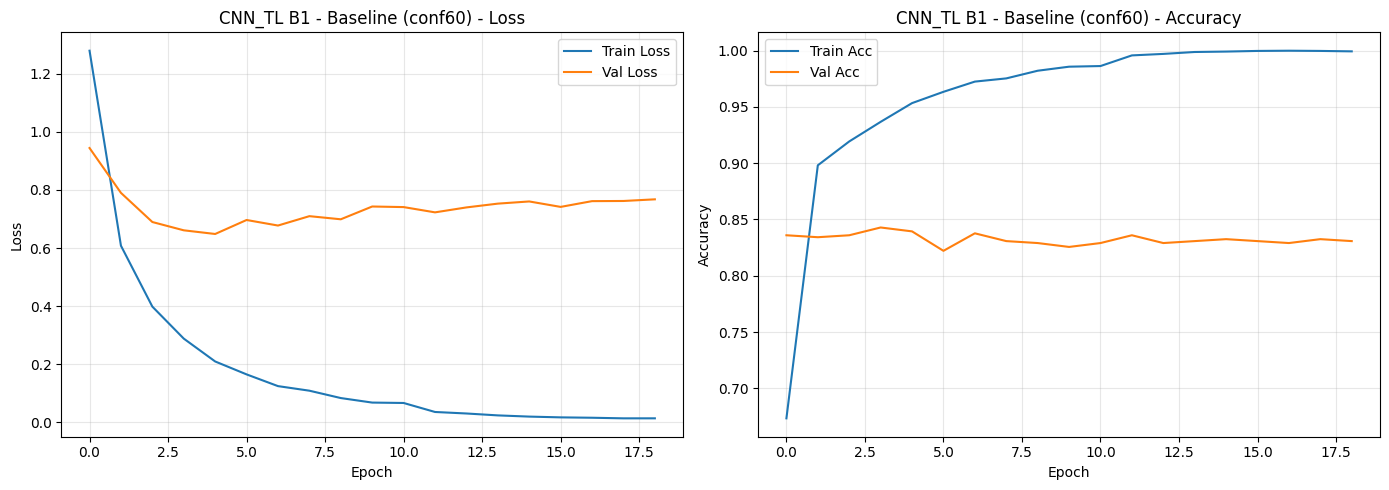

Test Loss: 0.6966
Test Accuracy: 0.7933
Test Macro F1: 0.2734
Test Weighted F1: 0.7820

Classification Report:
              precision    recall  f1-score   support

     neutral       0.84      0.91      0.87       688
       happy       0.64      0.48      0.55       183
         sad       0.48      0.50      0.49        50
       angry       0.00      0.00      0.00         2
     fearful       0.00      0.00      0.00         1
   disgusted       0.00      0.00      0.00         2
   surprised       0.00      0.00      0.00         3

    accuracy                           0.79       929
   macro avg       0.28      0.27      0.27       929
weighted avg       0.78      0.79      0.78       929



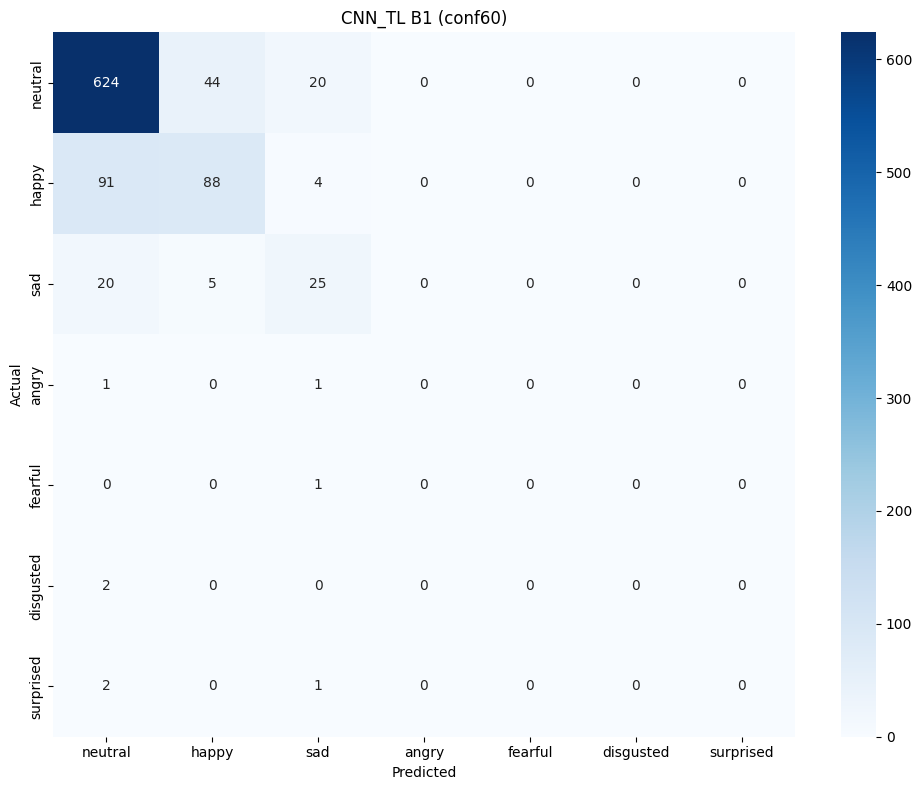

B1: Acc=0.7933 F1=0.2734

Class weights: None


Training B2 (class weights)...
 Epoch  Train Loss  Train Acc   Val Loss   Val Acc   Val F1         LR
---------------------------------------------------------------------------


     1      1.2953     0.6713     0.9523    0.8463   0.2228   0.000050  (18.0s)


     2      0.6147     0.8977     0.7267    0.8446   0.2216   0.000050  (18.0s)


     3      0.3936     0.9223     0.7114    0.8342   0.1824   0.000050  (18.1s)


...

    18      0.0125     0.9996     0.7139    0.8342   0.2208   0.000025  (18.1s)


    19      0.0105     0.9998     0.7156    0.8446   0.2225   0.000025  (18.1s)


    20      0.0100     0.9998     0.7288    0.8394   0.2115   0.000025  (18.1s)


    21      0.0089     0.9998     0.7519    0.8411   0.2138   0.000025  (18.1s)


    22      0.0080     1.0000     0.7364    0.8377   0.2127   0.000025  (18.1s)

Early stopping at epoch 22. Best epoch: 7 (val_f1=0.2243)

Best: epoch 7, val_acc=0.8463, val_f1=0.2243
Model saved: /home/bs000716/MOTHER-TANK/TRAIN/models/frontonly_conf60/7class_tl/cnn_tl_b2.pth


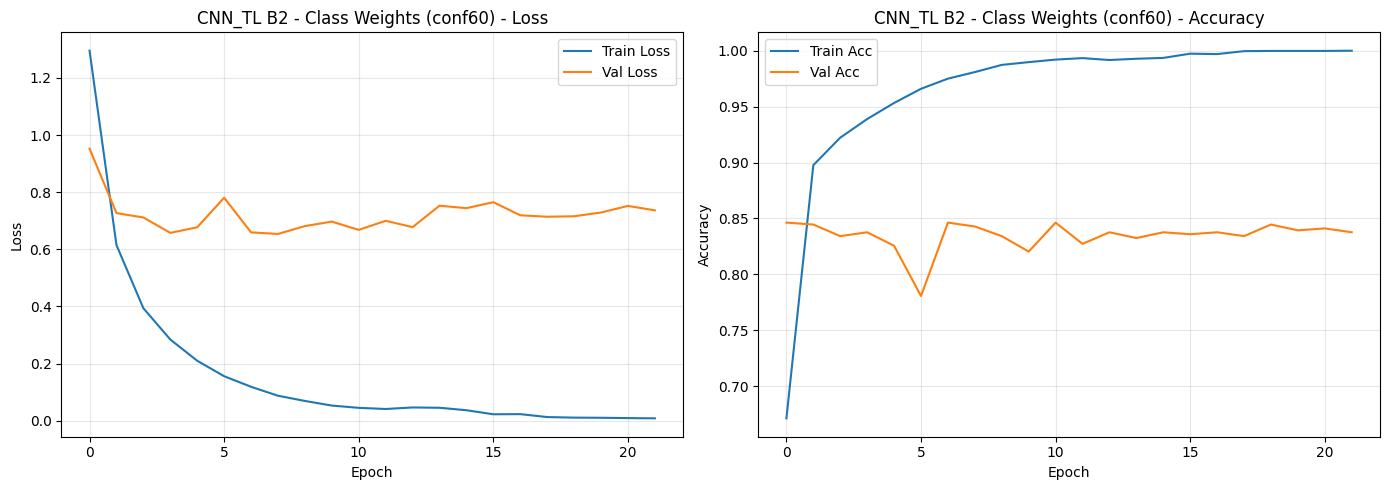

Test Loss: 0.7084
Test Accuracy: 0.7503
Test Macro F1: 0.2433
Test Weighted F1: 0.7462

Classification Report:
              precision    recall  f1-score   support

     neutral       0.84      0.84      0.84       688
       happy       0.50      0.56      0.53       183
         sad       0.40      0.28      0.33        50
       angry       0.00      0.00      0.00         2
     fearful       0.00      0.00      0.00         1
   disgusted       0.00      0.00      0.00         2
   surprised       0.00      0.00      0.00         3

    accuracy                           0.75       929
   macro avg       0.25      0.24      0.24       929
weighted avg       0.74      0.75      0.75       929



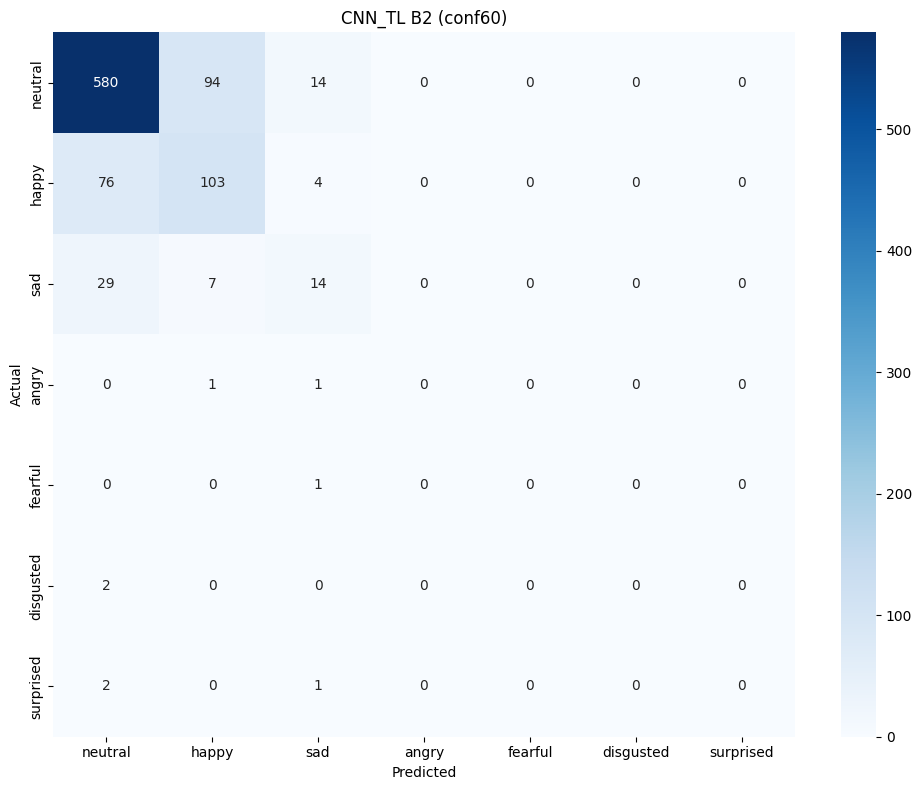

B2: Acc=0.7503 F1=0.2433


Train: 5829 | Val: 579 | Test: 929
     neutral: 4526
       happy: 416
         sad: 287
       angry: 150
     fearful: 150
   disgusted: 150
   surprised: 150



Training B3 (class weights + augmented)...
 Epoch  Train Loss  Train Acc   Val Loss   Val Acc   Val F1         LR
---------------------------------------------------------------------------


     1      1.1542     0.7027     1.0011    0.8221   0.1496   0.000050  (20.4s)


     2      0.5527     0.8868     0.7929    0.8359   0.1707   0.000050  (20.8s)


...

    19      0.0078     1.0000     0.8098    0.8359   0.1908   0.000025  (20.6s)


    20      0.0076     1.0000     0.8350    0.8342   0.1821   0.000025  (20.7s)


    21      0.0072     1.0000     0.8763    0.8377   0.1830   0.000025  (20.8s)


    22      0.0062     1.0000     0.8411    0.8325   0.1812   0.000025  (20.6s)


    23      0.0062     0.9998     0.9177    0.8342   0.1730   0.000025  (20.7s)

Early stopping at epoch 23. Best epoch: 8 (val_f1=0.2090)

Best: epoch 8, val_acc=0.8394, val_f1=0.2090
Model saved: /home/bs000716/MOTHER-TANK/TRAIN/models/frontonly_conf60/7class_tl/cnn_tl_b3.pth


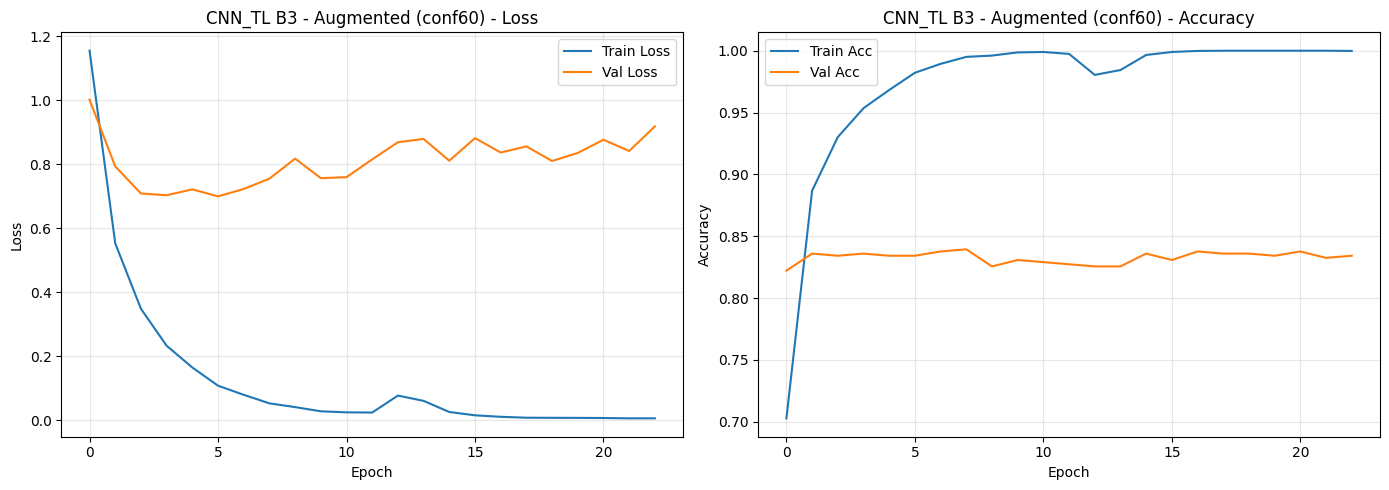

Test Loss: 0.5685
Test Accuracy: 0.8073
Test Macro F1: 0.2405
Test Weighted F1: 0.7969

Classification Report:
              precision    recall  f1-score   support

     neutral       0.89      0.86      0.88       688
       happy       0.64      0.83      0.72       183
         sad       0.13      0.06      0.08        50
       angry       0.00      0.00      0.00         2
     fearful       0.00      0.00      0.00         1
   disgusted       0.00      0.00      0.00         2
   surprised       0.00      0.00      0.00         3

    accuracy                           0.81       929
   macro avg       0.24      0.25      0.24       929
weighted avg       0.79      0.81      0.80       929



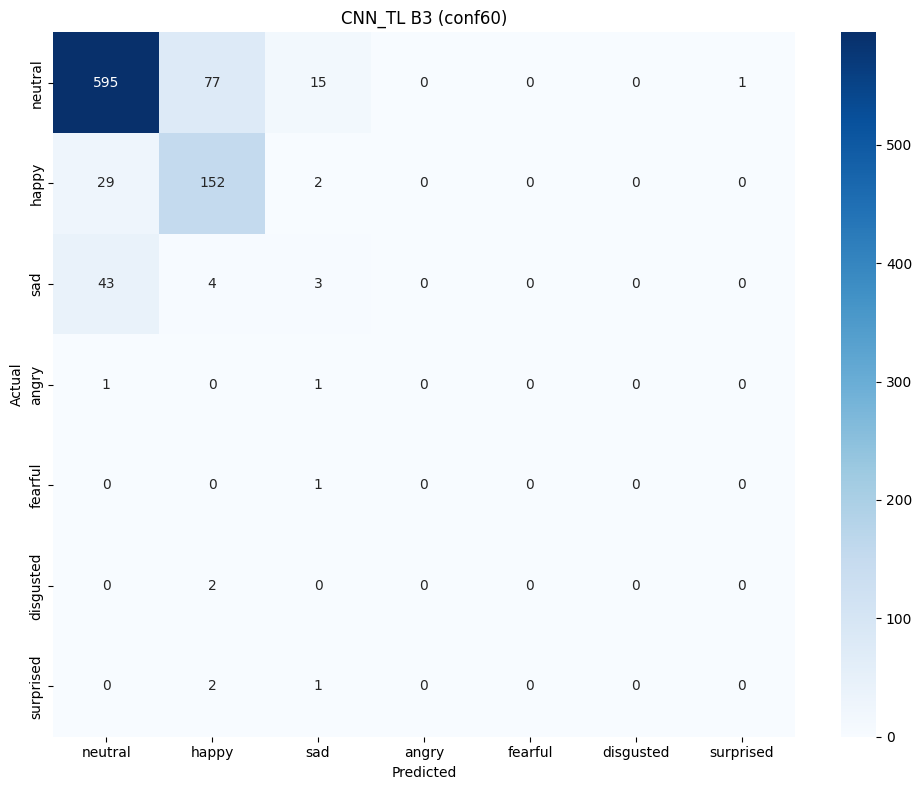

B3: Acc=0.8073 F1=0.2405

RINGKASAN CNN_TL (conf60)
  B1 Baseline               Acc=0.7933 F1=0.2734
  B2 Class Weights          Acc=0.7503 F1=0.2433
  B3 Weights+Aug            Acc=0.8073 F1=0.2405

Saved: /home/bs000716/MOTHER-TANK/TRAIN/models/frontonly_conf60/7class_tl/cnn_tl_results.json


In [3]:
all_results = {}

# B1: Baseline
model_b1 = EmotionCNNTransfer(num_classes=NUM_CLASSES).to(device)
criterion_b1 = nn.CrossEntropyLoss()
optimizer_b1 = torch.optim.Adam(model_b1.parameters(), lr=LR)
scheduler_b1 = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_b1, mode="max", factor=0.5, patience=8, min_lr=1e-7)
print("\nTraining B1 (baseline)...")
history_b1, _ = train_model(model_b1, train_loader, val_loader, criterion_b1, optimizer_b1, scheduler_b1,
    device, model_type="cnn", epochs=EPOCHS, patience=PATIENCE, save_path=str(OUTPUT_DIR / "cnn_tl_b1.pth"))
plot_training_history(history_b1, "CNN_TL B1 - Baseline (conf60)")
model_b1.load_state_dict(torch.load(OUTPUT_DIR / "cnn_tl_b1.pth", map_location=device, weights_only=True))
r_b1 = full_evaluation(model_b1, test_loader, criterion_b1, device, "cnn", EMOTIONS)
plot_confusion_matrix(r_b1["confusion_matrix"], "CNN_TL B1 (conf60)", EMOTIONS)
all_results["B1 Baseline"] = {"accuracy": float(r_b1["test_accuracy"]), "macro_f1": float(r_b1["test_macro_f1"]), "weighted_f1": float(r_b1["test_weighted_f1"])}
print(f"B1: Acc={r_b1['test_accuracy']:.4f} F1={r_b1['test_macro_f1']:.4f}")

# B2: Class Weights
weights = get_class_weights(DATASET_DIR, device)
print(f"\nClass weights: {weights}")
model_b2 = EmotionCNNTransfer(num_classes=NUM_CLASSES).to(device)
criterion_b2 = nn.CrossEntropyLoss(weight=weights)
optimizer_b2 = torch.optim.Adam(model_b2.parameters(), lr=LR)
scheduler_b2 = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_b2, mode="max", factor=0.5, patience=8, min_lr=1e-7)
print("Training B2 (class weights)...")
history_b2, _ = train_model(model_b2, train_loader, val_loader, criterion_b2, optimizer_b2, scheduler_b2,
    device, model_type="cnn", epochs=EPOCHS, patience=PATIENCE, save_path=str(OUTPUT_DIR / "cnn_tl_b2.pth"))
plot_training_history(history_b2, "CNN_TL B2 - Class Weights (conf60)")
model_b2.load_state_dict(torch.load(OUTPUT_DIR / "cnn_tl_b2.pth", map_location=device, weights_only=True))
r_b2 = full_evaluation(model_b2, test_loader, criterion_b2, device, "cnn", EMOTIONS)
plot_confusion_matrix(r_b2["confusion_matrix"], "CNN_TL B2 (conf60)", EMOTIONS)
all_results["B2 Class Weights"] = {"accuracy": float(r_b2["test_accuracy"]), "macro_f1": float(r_b2["test_macro_f1"]), "weighted_f1": float(r_b2["test_weighted_f1"])}
print(f"B2: Acc={r_b2['test_accuracy']:.4f} F1={r_b2['test_macro_f1']:.4f}")

# B3: Class Weights + Augmented
train_loader_aug, _, _ = load_dataloaders(DATASET_AUG_DIR, BATCH_SIZE)
weights_aug = get_class_weights(DATASET_AUG_DIR, device)
model_b3 = EmotionCNNTransfer(num_classes=NUM_CLASSES).to(device)
criterion_b3 = nn.CrossEntropyLoss(weight=weights_aug)
optimizer_b3 = torch.optim.Adam(model_b3.parameters(), lr=LR)
scheduler_b3 = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_b3, mode="max", factor=0.5, patience=8, min_lr=1e-7)
print("\nTraining B3 (class weights + augmented)...")
history_b3, _ = train_model(model_b3, train_loader_aug, val_loader, criterion_b3, optimizer_b3, scheduler_b3,
    device, model_type="cnn", epochs=EPOCHS, patience=PATIENCE, save_path=str(OUTPUT_DIR / "cnn_tl_b3.pth"))
plot_training_history(history_b3, "CNN_TL B3 - Augmented (conf60)")
model_b3.load_state_dict(torch.load(OUTPUT_DIR / "cnn_tl_b3.pth", map_location=device, weights_only=True))
r_b3 = full_evaluation(model_b3, test_loader, criterion_b3, device, "cnn", EMOTIONS)
plot_confusion_matrix(r_b3["confusion_matrix"], "CNN_TL B3 (conf60)", EMOTIONS)
all_results["B3 Weights+Aug"] = {"accuracy": float(r_b3["test_accuracy"]), "macro_f1": float(r_b3["test_macro_f1"]), "weighted_f1": float(r_b3["test_weighted_f1"])}
print(f"B3: Acc={r_b3['test_accuracy']:.4f} F1={r_b3['test_macro_f1']:.4f}")

# Summary
print("\n" + "=" * 60)
print("RINGKASAN CNN_TL (conf60)")
print("=" * 60)
for name, r in all_results.items():
    print(f"  {name:<25} Acc={r['accuracy']:.4f} F1={r['macro_f1']:.4f}")

with open(OUTPUT_DIR / "cnn_tl_results.json", "w") as f:
    json.dump(all_results, f, indent=2)
print(f"\nSaved: {OUTPUT_DIR / 'cnn_tl_results.json'}")